In [25]:
import nibabel as nib
import numpy as np
import os
from skimage.metrics import mean_squared_error
from skimage.metrics import structural_similarity
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

seg=nib.load("receptors_reg.nii")
segdata=seg.get_fdata()
etiquetes={1:'Caudat esquerre', 2:'Putamen esquerre',3:'Caudat dret',4:'Putamen dret',5:'Cerebel'}




In [26]:
#Cerebel com a regió de referecncia amb un valor de 5
def SUR(recdata,segdata,ref=5):
    recdata = recdata/np.max(recdata)
    SURarr=np.empty(ref-1)
  #B és la regió de referencia, de tota la segmentació m'interessa nomes aquella
    filtre = segdata==ref
    B=np.sum(recdata[filtre])/np.sum(filtre)
    for i in range(1,int(segdata.max())+1):
        #ara vull evitar el valor de referencia
        if i==ref:
            continue
        filtre = segdata==i
        S=np.sum(recdata[filtre])/np.sum(filtre)
        SUR=(S-B)/B
        SURarr[i-1]=SUR
    return SURarr



In [27]:
SUR_teor = [3,3,3,3]
SUR_teor = np.array(SUR_teor)

In [28]:

freqs=['002','01','03','05','07','09']
primari_SUR=np.empty((len(freqs),SUR_teor.size))
for i,freq in enumerate(freqs):
  rec = nib.load(f"Reconstruccions/reconstruccio1_{freq}.img")
  recdata = rec.get_fdata()[:,:,:,0]
  SURarr=SUR(recdata,segdata)
  primari_SUR[i,:]=SURarr

In [29]:
totals_SUR=np.empty((len(freqs),SUR_teor.size))
for i,freq in enumerate(freqs):
  rec=nib.load(f"Reconstruccions/reconstruccio3_{freq}.img")
  recdata = rec.get_fdata()[:,:,:,0]
  SURarr=SUR(recdata,segdata)
  totals_SUR[i,:]=SURarr



In [30]:
print(primari_SUR)

[[0.60727327 0.58048037 0.62232021 0.61492351]
 [1.70099503 2.0441048  1.71467259 1.91296543]
 [2.63565574 3.03056508 2.7409246  2.82138151]
 [2.69455334 3.0707459  2.7944968  2.86253946]
 [2.69697833 3.0699685  2.79853617 2.86664635]
 [2.69706277 3.069913   2.79869649 2.86681082]]


In [31]:
print(totals_SUR)

[[0.57919844 0.55207967 0.59463172 0.58509143]
 [1.57466143 1.86984153 1.58188598 1.74534972]
 [2.35692459 2.7192546  2.4493323  2.52264628]
 [2.41105301 2.75630945 2.49356357 2.5600302 ]
 [2.41439604 2.75535524 2.49638818 2.56289879]
 [2.41452941 2.75530459 2.49650305 2.56301719]]


Text(0, 0.5, 'CR')

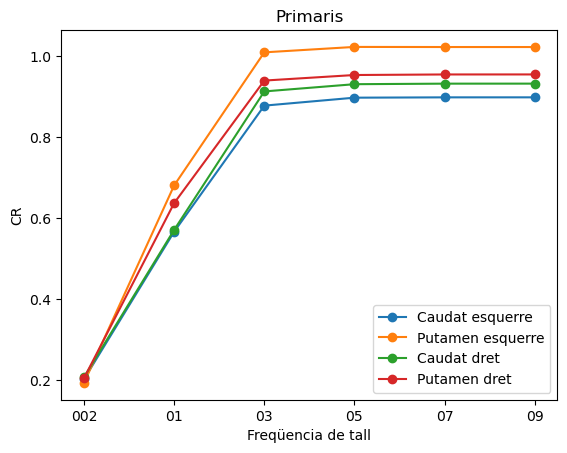

In [35]:
plt.plot(freqs,[i[0]/SUR_teor[0] for i in primari_SUR],"-o",label = "Caudat esquerre")
plt.plot(freqs,[i[1]/SUR_teor[1] for i in primari_SUR],"-o",label = "Putamen esquerre")
plt.plot(freqs,[i[2]/SUR_teor[2] for i in primari_SUR],"-o",label = "Caudat dret")
plt.plot(freqs,[i[3]/SUR_teor[3] for i in primari_SUR],"-o",label = "Putamen dret")
plt.title("Primaris")
plt.legend()
plt.xlabel("Freqüencia de tall")
plt.ylabel("CR")

Text(0, 0.5, 'CR')

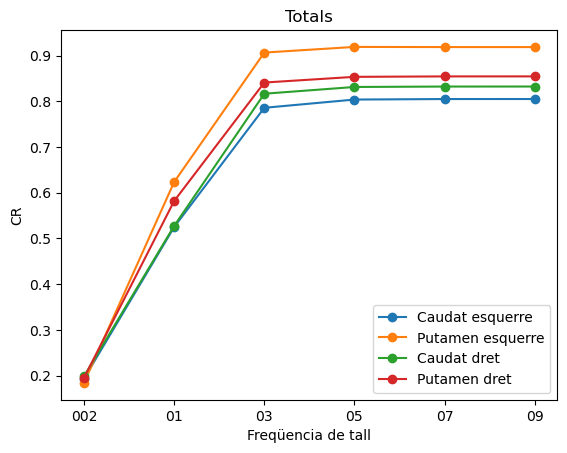

In [34]:
plt.plot(freqs,[i[0]/SUR_teor[0] for i in totals_SUR],"-o",label = "Caudat esquerre")
plt.plot(freqs,[i[1]/SUR_teor[1] for i in totals_SUR],"-o",label = "Putamen esquerre")
plt.plot(freqs,[i[2]/SUR_teor[2] for i in totals_SUR],"-o",label = "Caudat dret")
plt.plot(freqs,[i[3]/SUR_teor[3] for i in totals_SUR],"-o",label = "Putamen dret")
plt.title("Totals")
plt.legend()
plt.xlabel("Freqüencia de tall")
plt.ylabel("CR")

In [37]:
sum([i[1]/SUR_teor[1] for i in primari_SUR])/6

0.825876536858026

In [36]:
sum([i[1]/SUR_teor[1] for i in totals_SUR])/6

0.7448969488726137